In [1]:
import pandas as pd

# load data
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# clean data
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# prepare data
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

# convert categorical to numeric
X = pd.get_dummies(X, drop_first=True)

# ensure all numeric
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# train model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# evaluate
from sklearn.metrics import accuracy_score
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8109452736318408


In [3]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': pred
})

results.head(10)

,Actual,Predicted
6679,0,0
6448,1,0
2523,0,0
1056,1,1
1835,0,1
6786,1,0
5431,0,0
973,1,0
277,0,0
4393,1,1


In [5]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
print(cm)

#confusion matrix

[[938  88]
 [178 203]]


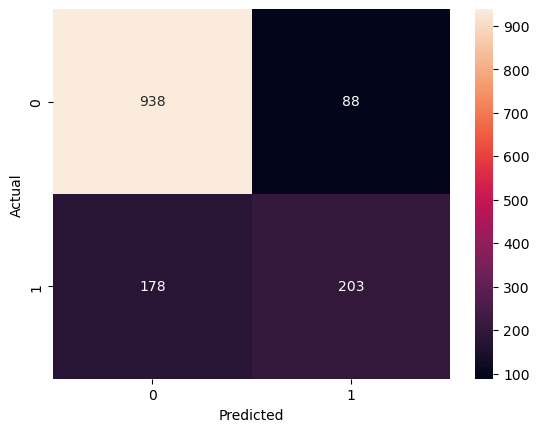

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
df.to_csv("churn_cleaned.csv", index=False)